Test notebook to demonstrate how to open individual files and plot variables without using Coffea. Useful for simple studies.

In [1]:
import uproot
import vector
import numpy as np
import matplotlib.pyplot as plt
import awkward as ak

In [12]:
# Fill in the path to your individual llpNanoAOD files here 
# Note: the symbol ~ means your home directory, or the top directory in the file tree
file_path = "~/data_files/"
file_names = ["nano_1000_0p25_0p002.root"]


branches_dict = {}

for file_name in file_names:
    print("Opening ",file_path+file_name)
    temp_file = uproot.open(file_path+file_name)
    tree = temp_file['Events']
    #Load all the branches into memory and store in branches_dict (this is slow, and could be done in a 
    #"lazy" way to only read the arrays that we end up using, but I'm too lazy to be lazy)
    branches_dict[file_name] = tree.arrays()
branches = branches_dict[file_names[0]] #store the data from the last file into the branches variable

Opening  ~/data_files/nano_1000_0p25_0p002.root


In [10]:
#Explore the branches in the files
tree.keys(filter_name="Muon*")

['Muon_dxy',
 'Muon_dxyErr',
 'Muon_dxybs',
 'Muon_dz',
 'Muon_dzErr',
 'Muon_eta',
 'Muon_ip3d',
 'Muon_jetPtRelv2',
 'Muon_jetRelIso',
 'Muon_mass',
 'Muon_miniPFRelIso_all',
 'Muon_miniPFRelIso_chg',
 'Muon_pfRelIso03_all',
 'Muon_pfRelIso03_chg',
 'Muon_pfRelIso04_all',
 'Muon_phi',
 'Muon_pt',
 'Muon_ptErr',
 'Muon_segmentComp',
 'Muon_sip3d',
 'Muon_softMva',
 'Muon_tkRelIso',
 'Muon_tunepRelPt',
 'Muon_mvaLowPt',
 'Muon_mvaTTH',
 'Muon_charge',
 'Muon_jetIdx',
 'Muon_nStations',
 'Muon_nTrackerLayers',
 'Muon_pdgId',
 'Muon_tightCharge',
 'Muon_fsrPhotonIdx',
 'Muon_highPtId',
 'Muon_highPurity',
 'Muon_inTimeMuon',
 'Muon_isGlobal',
 'Muon_isPFcand',
 'Muon_isStandalone',
 'Muon_isTracker',
 'Muon_jetNDauCharged',
 'Muon_looseId',
 'Muon_mediumId',
 'Muon_mediumPromptId',
 'Muon_miniIsoId',
 'Muon_multiIsoId',
 'Muon_mvaId',
 'Muon_mvaLowPtId',
 'Muon_pfIsoId',
 'Muon_puppiIsoId',
 'Muon_softId',
 'Muon_softMvaId',
 'Muon_tightId',
 'Muon_tkIsoId',
 'Muon_triggerIdLoose',
 'Muo

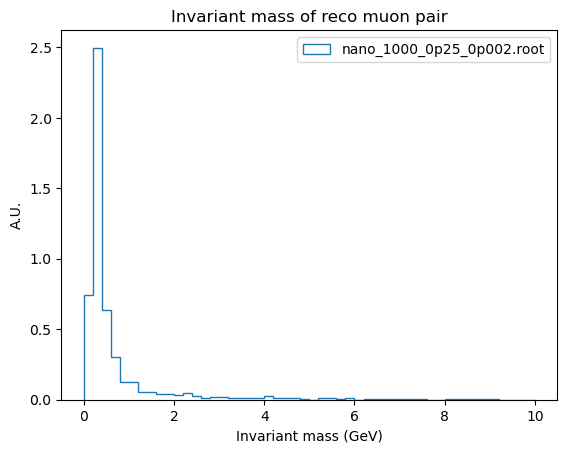

In [13]:
#Plot the invariant mass of the reconstructed muon pair (should peak at the dark photon mass)

#Create a vector object for the muons
muon_p4 = vector.zip({"pt": branches['Muon_pt'],
                      "eta": branches['Muon_eta'],
                      "phi": branches['Muon_phi'],
                      "mass": branches['Muon_mass']})

#Apply quality cuts to muons (could add more here)
good_muon_mask = (muon_p4.pt > 0)  #muon level mask

#Apply the mask
good_muons = muon_p4[good_muon_mask]

#Select events with at least two good muons
two_muons_mask = ak.count(good_muons.pt,1) >= 2 #event level mask
two_muons_p4 = good_muons[two_muons_mask]

first_muon_p4 = two_muons_p4[:, 0]
second_muon_p4 = two_muons_p4[:, 1]
muon_sum_p4 = first_muon_p4 + second_muon_p4 #event level quantity
plt.hist(muon_sum_p4.mass, bins=50, range=(0, 10), label = file_name,histtype='step',density=True)
plt.xlabel('Invariant mass (GeV)')
plt.ylabel('A.U.')
plt.title('Invariant mass of reco muon pair')
plt.legend(loc = 'upper right')